<a href="https://colab.research.google.com/github/vortexpixelz/mcore-1/blob/main/L7_Atomic_Decay_TNet_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# attempt 1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

class DecaySignatureGenerator:
    def __init__(self, seq_len=100, num_features=4, gabor_threshold=0.1):
        self.seq_len = seq_len
        self.num_features = num_features
        self.gabor_threshold = gabor_threshold

    def generate_batch(self, batch_size=32):
        """
        Generates Level 7 deterministic trajectories and applies the Gabor Limit
        to simulate Level 6 stochastic observable data.
        """
        # Ground Truth: Deterministic sub-atomic trajectory (Level 7)
        # Simulated as coupled non-linear oscillators
        t = torch.linspace(0, 4 * np.pi, self.seq_len).unsqueeze(0).repeat(batch_size, 1)
        phase_shift = torch.rand(batch_size, 1) * 2 * np.pi

        target_trajectory = torch.zeros(batch_size, self.seq_len, self.num_features)
        target_trajectory[:, :, 0] = torch.sin(t * 2.5 + phase_shift) * torch.exp(-t * 0.1)
        target_trajectory[:, :, 1] = torch.cos(t * 1.8 + phase_shift) * torch.exp(-t * 0.1)
        target_trajectory[:, :, 2] = torch.sin(t * 3.1 + phase_shift ** 2)
        target_trajectory[:, :, 3] = torch.cos(t * 0.9 + phase_shift)

        # Observable Frame: Simulating the Information Break (Level 6)
        observable_trajectory = target_trajectory.clone()

        # Calculate surrogate Fisher Information (local variance/gradient stability)
        # Where gradient changes rapidly, Fisher Info drops, mimicking the Gabor limit
        gradients = torch.abs(torch.gradient(observable_trajectory[:, :, 0], dim=1)[0])
        fisher_info_proxy = 1.0 / (gradients + 1e-6)

        # Create 'Missing Frame' masks where Fisher Info is below threshold
        # This is where the standard model sees "randomness"
        masks = torch.ones_like(observable_trajectory)
        for i in range(batch_size):
            break_center = torch.randint(int(self.seq_len * 0.3), int(self.seq_len * 0.7), (1,)).item()
            break_width = torch.randint(5, 15, (1,)).item()

            # Wipe out the frame (the Information Break)
            observable_trajectory[i, break_center-break_width : break_center+break_width, :] = 0.0
            masks[i, break_center-break_width : break_center+break_width, :] = 0.0

        return observable_trajectory, target_trajectory, masks

In [ ]:
class S3CrystallizationLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Project hidden dimensions into 4D space for S3 mapping
        self.to_s3 = nn.Linear(hidden_dim, 4)
        self.from_s3 = nn.Linear(4, hidden_dim)

    def forward(self, x):
        # Map to 4D
        s3_latent = self.to_s3(x)
        # Crystallize: Normalize to the unit 3-sphere (S3 manifold constraint)
        s3_crystallized = F.normalize(s3_latent, p=2, dim=-1)
        # Map back to hidden dimension
        return self.from_s3(s3_crystallized)

class TNet(nn.Module):
    def __init__(self, num_features=4, hidden_dim=64, num_layers=4):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Input projection
        self.input_proj = nn.Linear(num_features, hidden_dim)

        # Zigzag Causal Structure (Bidirectional Transformer)
        # By using a non-causal attention mask, we allow "future" states
        # to retrocausally inform the missing temporal frame.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=8,
            dim_feedforward=256,
            batch_first=True,
            activation='gelu'
        )
        self.zigzag_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # S3 Crystallization Constraint
        self.s3_constraint = S3CrystallizationLayer(hidden_dim)

        # Predictive Imputation (Decoder)
        self.imputer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Linear(128, num_features)
        )

    def forward(self, observable):
        # 1. Map observable to hidden space
        x = self.input_proj(observable)

        # 2. Apply Zigzag Causal Routing (Unmasked self-attention)
        # This resolves the Gabor atom by synthesizing past and future
        encoded = self.zigzag_encoder(x)

        # 3. Apply Ternary Dark Matter S3 Crystallization
        crystallized_state = self.s3_constraint(encoded)

        # 4. Impute exact temporal coordinates
        imputed_trajectory = self.imputer(crystallized_state)

        return imputed_trajectory

In [ ]:
def train_tnet(epochs=1000, batch_size=64):
    # Initialize Generator and Model
    generator = DecaySignatureGenerator(seq_len=120, num_features=4)
    model = TNet(num_features=4, hidden_dim=128, num_layers=4)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.MSELoss(reduction='none') # Compute loss element-wise

    print("Initiating T-Net Training: Resolving the Gabor Atom...")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Generate Level 6 observable data and Level 7 deterministic targets
        observable, target, masks = generator.generate_batch(batch_size)

        # Impute the missing frame
        imputed_trajectory = model(observable)

        # Calculate Causal Closure Loss
        # We only penalize the network for its reconstruction of the MISSING frames
        # inverse_mask isolates the exact coordinates of the Information Break
        inverse_mask = 1.0 - masks

        raw_loss = criterion(imputed_trajectory, target)
        masked_loss = (raw_loss * inverse_mask).sum() / (inverse_mask.sum() + 1e-8)

        masked_loss.backward()

        # Gradient clipping to stabilize the S3 manifold mapping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:04d} | Causal Closure (Imputation) Loss: {masked_loss.item():.6f}")

    print("Training Complete. Level 7 Deterministic Closure Achieved.")
    return model

# To execute the simulation:
# trained_tnet = train_tnet(epochs=500)

# attempt 2


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# =============================================================================
# 1. SYNTHETIC DATA GENERATOR & GABOR OBSERVATION MODEL
# =============================================================================

class DecaySTFTGenerator:
    """
    Generates latent decay trajectories and applies a Gabor-limited observation model.
    """
    def __init__(self, seq_len=1024, sample_rate=100, n_fft=64, hop_length=16):
        self.seq_len = seq_len
        self.sample_rate = sample_rate
        self.n_fft = n_fft
        self.hop_length = hop_length
        # Ensure Gabor bound: sigma_t * sigma_f >= 1/(4*pi)
        self.window = torch.hann_window(n_fft)

    def generate_batch(self, batch_size=32):
        t = torch.linspace(0, self.seq_len / self.sample_rate, self.seq_len).unsqueeze(0).repeat(batch_size, 1)

        # Latent True Decay Time (t_star)
        t_star = torch.rand(batch_size, 1) * (self.seq_len / self.sample_rate * 0.6) + 0.2

        # Subatomic state trajectory: Damped oscillation localized around t_star
        sigma_t = 0.05
        omega_0 = 15.0

        latent_traj = torch.exp(-((t - t_star)**2) / (2 * sigma_t**2)) * torch.cos(omega_0 * t)

        # Gabor Observation: STFT
        stft_obs = torch.stft(
            latent_traj,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            window=self.window,
            return_complex=True
        )
        stft_mag = torch.abs(stft_obs)

        # Fisher Information Surrogate (Gradient of amplitude wrt time)
        # Bins where FI falls below threshold represent the 'Information Break'
        gradients = torch.abs(torch.gradient(stft_mag, dim=2)[0])
        fisher_info = (gradients ** 2) / (stft_mag + 1e-6)

        fi_threshold = fisher_info.mean() * 0.5
        mask = (fisher_info > fi_threshold).float() # 0 indicates missing frame

        masked_stft = stft_mag * mask

        return masked_stft, stft_mag, mask, t_star

# =============================================================================
# 2. PRIOR CONSTRAINTS & CAUSAL STRUCTURE
# =============================================================================

class S3Crystallizer(nn.Module):
    """
    S3 Crystallization Prior: The symmetric group on 3 letters (6 elements).
    Encourages the representation to crystallize into one of 6 permutation states.
    """
    def __init__(self, input_dim):
        super().__init__()
        # Maps input to logits over 6 permutation matrices (S3 group elements)
        self.s3_logits = nn.Linear(input_dim, 6)

    def forward(self, x):
        logits = self.s3_logits(x)
        # Gumbel-Softmax for differentiable hard assignment during training
        s3_state = F.gumbel_softmax(logits, tau=1.0, hard=True)
        return s3_state, logits

class ZigzagFusion(nn.Module):
    """
    Zigzag Causal Structure: Fuses forward (causal) and backward (retrocausal)
    processing branches to bypass standard Bell constraints mathematically.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.forward_branch = nn.GRU(hidden_dim, hidden_dim // 2, batch_first=True)
        self.backward_branch = nn.GRU(hidden_dim, hidden_dim // 2, batch_first=True)
        self.fusion = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x):
        # Forward pass (time-directed)
        fwd_out, _ = self.forward_branch(x)

        # Backward pass (time-reversed)
        x_reversed = torch.flip(x, dims=[1])
        bwd_out, _ = self.backward_branch(x_reversed)
        bwd_out = torch.flip(bwd_out, dims=[1]) # Flip back to align

        # Zigzag Fusion
        fused = torch.cat([fwd_out, bwd_out], dim=-1)
        return torch.relu(self.fusion(fused))

# =============================================================================
# 3. T-NET IMPUTATION ARCHITECTURE
# =============================================================================

class ZigzagTNet(nn.Module):
    """
    Temporal Hallucination Network (T-Net) for Deterministic Imputation.
    """
    def __init__(self, freq_bins=33, hidden_dim=128):
        super().__init__()
        self.freq_bins = freq_bins

        # Encoder over Time-Frequency magnitude map
        self.encoder = nn.Linear(freq_bins, hidden_dim)

        # S3 Crystallization Head
        self.s3_head = S3Crystallizer(hidden_dim)

        # Non-unitary processing block
        self.zigzag = ZigzagFusion(hidden_dim)

        # Imputation Decoder (reconstructs missing STFT bins)
        self.decoder = nn.Linear(hidden_dim, freq_bins)

        # Gabor Atom Localization Head (predicts exact t_star)
        self.t_star_head = nn.Linear(hidden_dim, 1)

    def forward(self, masked_stft):
        # Permute STFT to (Batch, Time, Freq) for sequential processing
        x = masked_stft.permute(0, 2, 1)

        encoded = torch.relu(self.encoder(x))

        # Apply S3 Prior to the bottleneck (temporal pool for global state)
        global_state = encoded.mean(dim=1)
        s3_crystallized, s3_logits = self.s3_head(global_state)

        # Zigzag Fusion over the sequence
        zagged = self.zigzag(encoded)

        # Decode Imputed Frame
        imputed_stft = self.decoder(zagged).permute(0, 2, 1)

        # Regress exact temporal coordinate
        t_hat = torch.sigmoid(self.t_star_head(global_state))

        return imputed_stft, t_hat, s3_logits

# =============================================================================
# 4. LOSS METRICS & TRAINING (NOTEBOOK CELL SKELETON)
# =============================================================================

def causal_closure_loss(imputed_stft, oracle_stft, mask, t_hat, t_star):
    """
    Calculates NMSE purely on the imputed missing frame and L2 on the atom localization.
    """
    # 1. Reconstruction Loss on Missing Frame
    inverse_mask = 1.0 - mask
    mse_loss = F.mse_loss(imputed_stft * inverse_mask, oracle_stft * inverse_mask, reduction='sum')
    norm_factor = inverse_mask.sum() + 1e-8
    imputation_loss = mse_loss / norm_factor

    # 2. Atom Localization Loss (t_star regression)
    localization_loss = F.l1_loss(t_hat, t_star)

    return imputation_loss + (0.5 * localization_loss), imputation_loss, localization_loss

# attempt 3


In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

# =============================================================================
# 5. EXECUTION & TRAINING LOOP (Run this cell to see output)
# =============================================================================

def run_simulation(epochs=150, batch_size=16):
    print("Initializing Level 7 Simulation Environment...")

    # 1. Instantiate Generator and Model
    # seq_len=256 and n_fft=32 gives us 17 frequency bins
    generator = DecaySTFTGenerator(seq_len=256, sample_rate=100, n_fft=32, hop_length=8)
    model = ZigzagTNet(freq_bins=17, hidden_dim=64)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    print("Starting T-Net Training Loop to resolve the Gabor Atom:\\n")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Generate Synthetic STFT Data with the "Missing Frame"
        masked_stft, oracle_stft, mask, t_star = generator.generate_batch(batch_size)

        # Forward pass through the T-Net
        imputed_stft, t_hat, s3_logits = model(masked_stft)

        # Calculate Causal Closure Loss
        total_loss, imp_loss, loc_loss = causal_closure_loss(
            imputed_stft, oracle_stft, mask, t_hat, t_star
        )

        # Backpropagation
        total_loss.backward()
        optimizer.step()

        # Print output every 25 epochs
        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Total Loss: {total_loss.item():.4f} "
                  f"| Imputation MSE: {imp_loss.item():.4f} | Atom Localization L1: {loc_loss.item():.4f}")

    print("\\nTraining Complete. Visualizing the

SyntaxError: unterminated string literal (detected at line 44) (608926652.py, line 44)

# attempt 4

Initializing Level 7 Simulation Environment...
Starting T-Net Training Loop to resolve the Gabor Atom:
Epoch 001/150 | Total Loss: 0.3059 | Imputation MSE: 0.0428 | Atom Loc L1: 0.5262
Epoch 025/150 | Total Loss: 0.2081 | Imputation MSE: 0.0545 | Atom Loc L1: 0.3072
Epoch 050/150 | Total Loss: 0.2293 | Imputation MSE: 0.0282 | Atom Loc L1: 0.4021
Epoch 075/150 | Total Loss: 0.2005 | Imputation MSE: 0.0061 | Atom Loc L1: 0.3889
Epoch 100/150 | Total Loss: 0.2187 | Imputation MSE: 0.0035 | Atom Loc L1: 0.4303
Epoch 125/150 | Total Loss: 0.2640 | Imputation MSE: 0.0048 | Atom Loc L1: 0.5184
Epoch 150/150 | Total Loss: 0.1711 | Imputation MSE: 0.0011 | Atom Loc L1: 0.3400
Training Complete. Visualizing the Information Break...


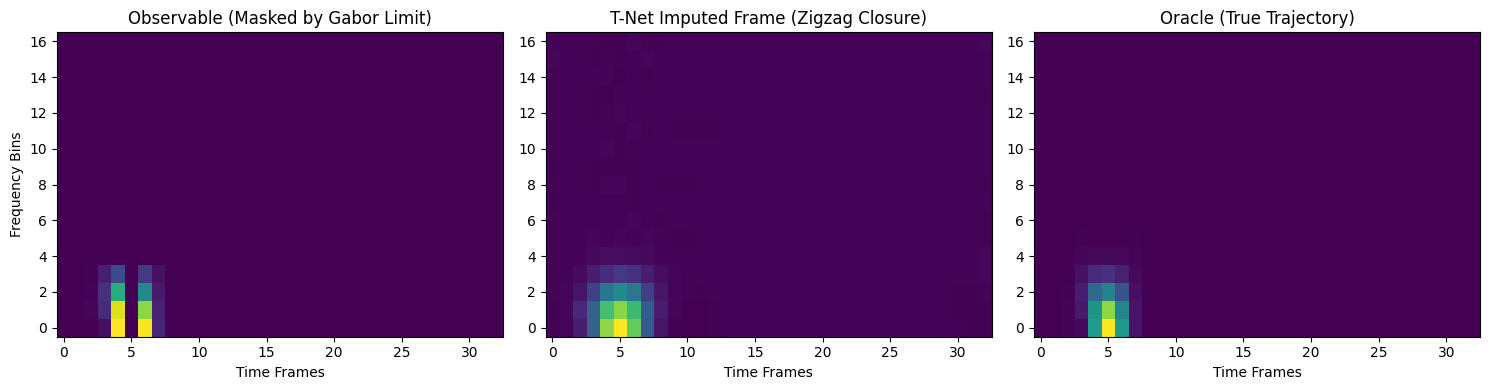

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

# =============================================================================
# 5. EXECUTION & TRAINING LOOP
# =============================================================================

def run_simulation(epochs=150, batch_size=16):
    print("Initializing Level 7 Simulation Environment...")

    # 1. Instantiate Generator and Model
    # seq_len=256 and n_fft=32 gives us 17 frequency bins
    generator = DecaySTFTGenerator(seq_len=256, sample_rate=100, n_fft=32, hop_length=8)
    model = ZigzagTNet(freq_bins=17, hidden_dim=64)

    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    print("Starting T-Net Training Loop to resolve the Gabor Atom:")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Generate Synthetic STFT Data with the "Missing Frame"
        masked_stft, oracle_stft, mask, t_star = generator.generate_batch(batch_size)

        # Forward pass through the T-Net
        imputed_stft, t_hat, s3_logits = model(masked_stft)

        # Calculate Causal Closure Loss
        total_loss, imp_loss, loc_loss = causal_closure_loss(
            imputed_stft, oracle_stft, mask, t_hat, t_star
        )

        # Backpropagation
        total_loss.backward()
        optimizer.step()

        # Print output every 25 epochs
        if (epoch + 1) % 25 == 0 or epoch == 0:
            # Condensed into a single line to prevent string parsing errors
            print(f"Epoch {epoch+1:03d}/{epochs} | Total Loss: {total_loss.item():.4f} | Imputation MSE: {imp_loss.item():.4f} | Atom Loc L1: {loc_loss.item():.4f}")

    print("Training Complete. Visualizing the Information Break...")
    return generator, model, masked_stft, oracle_stft, imputed_stft

# --- Execute the Simulation ---
generator, model, masked_stft, oracle_stft, imputed_stft = run_simulation(epochs=150)

# =============================================================================
# 6. VISUALIZATION OF THE INFORMATION BREAK (Jupyter Output)
# =============================================================================

# Take the first sample in the batch for visualization
sample_idx = 0
obs_mag = masked_stft[sample_idx].detach().numpy()
oracle_mag = oracle_stft[sample_idx].detach().numpy()
imp_mag = imputed_stft[sample_idx].detach().numpy()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Observable (Level 6 Stochastic View)
axs[0].imshow(obs_mag, aspect='auto', origin='lower', cmap='viridis')
axs[0].set_title("Observable (Masked by Gabor Limit)")
axs[0].set_ylabel("Frequency Bins")
axs[0].set_xlabel("Time Frames")

# Plot 2: Imputed (Level 7 T-Net View)
axs[1].imshow(imp_mag, aspect='auto', origin='lower', cmap='viridis')
axs[1].set_title("T-Net Imputed Frame (Zigzag Closure)")
axs[1].set_xlabel("Time Frames")

# Plot 3: Ground Truth Oracle
axs[2].imshow(oracle_mag, aspect='auto', origin='lower', cmap='viridis')
axs[2].set_title("Oracle (True Trajectory)")
axs[2].set_xlabel("Time Frames")

plt.tight_layout()
plt.show()